# Causal Discovery and Inference: A Medical Tutorial

**Tools:** `pgmpy` for causal discovery (learning the DAG from data) and `DoWhy` for causal inference (estimating treatment effects).

## The big idea

A *causal graph* tells us **which variables to adjust for** to remove confounding. Causal discovery learns this graph from data; causal inference uses it to estimate effects. The two libraries fit together naturally.

## Setup

Install dependencies if needed:

```bash
pip install pgmpy dowhy pandas numpy networkx matplotlib lingam 
```

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import networkx as nx
from pgmpy.causal_discovery import ExpertKnowledge
import matplotlib.pyplot as plt
from lingam.utils import make_dot
import pgmpy
import dowhy
from pgmpy.estimators import HillClimbSearch
print(f"pgmpy:  {pgmpy.__version__}")
print(f"dowhy:  {dowhy.__version__}")

np.random.seed(42)

pgmpy:  1.1.2
dowhy:  0.14


In [4]:
"""Plot a directed acyclic graph."""
def plot_dag(edges, title="DAG", highlight_treatment_outcome=True, ax=None):
   
    G = nx.DiGraph()
    G.add_edges_from(edges)
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    pos = {
        'Age': (0, 2), 'Smoking': (1, 3), 'Exercise': (1, 1), 'BMI': (2, 0),
        'Treatment': (1, 2), 'Cholesterol': (3, 2), 'BP': (3, 1),
        'HeartDisease': (5, 1.5),
    }
    for n in G.nodes():
        if n not in pos:
            pos[n] = (np.random.rand(), np.random.rand())

    colors = []
    for n in G.nodes():
        if highlight_treatment_outcome and n == 'Treatment':
            colors.append('#4CAF50')
        elif highlight_treatment_outcome and n == 'HeartDisease':
            colors.append('#F44336')
        else:
            colors.append('#90CAF9')

    nx.draw(G, pos, ax=ax, with_labels=True, node_color=colors,
            node_size=2200, font_size=9, font_weight='bold',
            arrows=True, arrowsize=18, edge_color='#555',
            connectionstyle="arc3,rad=0.05")
    ax.set_title(title, fontsize=13)
    return G

##  The medical dataset

We simulate a cardiovascular study with **2,000 patients** and 8 binary variables. Using synthetic data lets us validate causal discovery against a known ground truth — a luxury we never have with real data.

### Ground-truth causal structure

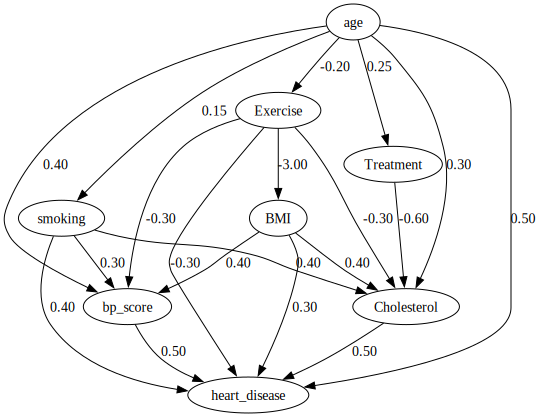

In [5]:
m = np.array([[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],#age
              [0.15, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],#smoking
              [-0.20, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],#Exercise
              [0.0, 0.0, -3.0, 0.0, 0.0, 0.0, 0.0, 0.0],#BMI
              [0.25, 0.0,0.0, 0.0, 0.0, 0.0, 0.0, 0.0],#treatment
              [0.3, 0.4,- 0.3, 0.4,-0.6, 0.0, 0.0, 0.0],#Cholesterol
              [0.4, 0.3,- 0.3, 0.4, 0.0, 0.0, 0.0, 0.0],#bp_score
              [0.5, 0.4, -0.3, 0.3, 0.0, 0.5, 0.5, 0.0]])#heart_disease
dot = make_dot(m,labels=["age","smoking","Exercise","BMI","Treatment","Cholesterol", "bp_score", "heart_disease"])
"""Simulate a cardiovascular study with known causal structure."""
true_edges = [
    ('Age', 'Smoking'), ('Age', 'Exercise'), ('Age', 'Treatment'),
    ('Age', 'BP'), ('Age', 'Cholesterol'), ('Age', 'HeartDisease'),
    ('Smoking', 'Cholesterol'), ('Smoking', 'BP'), ('Smoking', 'HeartDisease'),
    ('Exercise', 'BMI'), ('Exercise', 'BP'), ('Exercise', 'Cholesterol'),
    ('Exercise', 'HeartDisease'),
    ('BMI', 'BP'), ('BMI', 'Cholesterol'), ('BMI', 'HeartDisease'),
    ('Treatment', 'Cholesterol'),
    ('BP', 'HeartDisease'), ('Cholesterol', 'HeartDisease'),
]
def generate_medical_data(n=2000, seed=42):
    
    rng = np.random.default_rng(seed)

    # Age: 1 = older (>50)
    age = (rng.normal(50, 15, n).clip(20, 85) > 50).astype(int)

    # Smoking depends on age
    smoking = rng.binomial(1, 0.20 + 0.15 * age)

    # Exercise depends on age (older -> less)
    exercise = rng.binomial(1, 0.60 - 0.20 * age)

    # BMI depends on exercise (body mass index (BMI))
    bmi = ((26 - 3 * exercise + rng.normal(0, 2, n)) > 25).astype(int)

    # Treatment (statin): doctors prescribe more to older patients
    treatment = rng.binomial(1, 0.15 + 0.25 * age)

    # Cholesterol: age, smoking, no exercise, bmi -> high; treatment -> low
    chol_score = (0.3*age + 0.4*smoking - 0.3*exercise + 0.4*bmi
                  - 0.6*treatment + rng.normal(0, 0.3, n))
    cholesterol = (chol_score > 0.2).astype(int)

    # Blood pressure: age, smoking, no exercise, bmi -> high
    bp_score = 0.4*age + 0.3*smoking - 0.3*exercise + 0.4*bmi + rng.normal(0, 0.3, n)
    bp = (bp_score > 0.3).astype(int)

    # Heart disease: the outcome
    hd_score = (0.5*age + 0.4*smoking + 0.5*bp + 0.5*cholesterol
                - 0.3*exercise + 0.3*bmi + rng.normal(0, 0.4, n))
    heart_disease = (hd_score > 0.8).astype(int)

    return pd.DataFrame({
        'Age': age, 'Smoking': smoking, 'Exercise': exercise, 'BMI': bmi,
        'Treatment': treatment, 'Cholesterol': cholesterol, 'BP': bp,
        'HeartDisease': heart_disease
    })

dot

In [6]:
df = generate_medical_data()
print(f"\nShape: {df.shape}")
df.head()


Shape: (2000, 8)


,Age,Smoking,Exercise,BMI,Treatment,Cholesterol,BP,HeartDisease
0,1,0,0,1,0,1,1,1
1,0,0,1,0,0,0,0,0
2,1,0,0,1,0,1,1,1
3,1,0,0,1,1,0,1,1
4,0,0,0,1,0,1,1,0


We compare first theh heart disease rates between treated and untreated patients, exactly what a basic A/B test would do.

In [7]:
naive_ate = (df.groupby('Treatment')['HeartDisease'].mean())
print("P(HeartDisease | Treatment):")
print(naive_ate.round(3))
print(f"\nNaive ATE estimate: {naive_ate[1] - naive_ate[0]:+.4f}")
print("\n>>> Treated patients appear to have HIGHER heart disease rates!")
print(">>> This is the confounding problem: older, sicker patients get statins.")

P(HeartDisease | Treatment):
Treatment
0    0.479
1    0.519
Name: HeartDisease, dtype: float64

Naive ATE estimate: +0.0399

>>> Treated patients appear to have HIGHER heart disease rates!
>>> This is the confounding problem: older, sicker patients get statins.


##  Causal discovery with `pgmpy`

`pgmpy.estimators` provides several DAG-learning algorithms. We'll use two complementary ones:

| Algorithm | Type | How it works |
|---|---|---|
| **PC** | Constraint-based | Removes edges using conditional independence tests, then orients them using v-structure rules. Returns a CPDAG (some edges may be undirected). |
| **HillClimbSearch** | Score-based | Greedy search: adds, removes, and reverses edges to maximize a score (BIC, K2, BDeu). |

The PC algorithm gives statistical guarantees under strong assumptions; hill-climbing is more flexible but can get stuck in local optima. 

### Available CI tests in `pgmpy`

| Test | Data type | Notes |
|---|---|---|
| `chi_square` | discrete | Pearson chi-square; classic choice |
| `g_sq` | discrete | Likelihood-ratio variant of chi-square |
| `Log_likelihood` | discrete | Likelihood |
| `power_divergence` | discrete | Generalized family covering chi-square and G |
| `pearsonr` | continuous, **linear** | Tests partial correlation; Gaussian assumption |
| `pillai_trace` | mixed | Multivariate test, handles mixed types |
| `gcm` | continuous | Generalized covariance measure |
| `independence_match` | (any) | Uses provided independence oracle |


### The PC algorithm

The PC algorithm starts with a fully connected graph and removes an edge `X — Y` whenever it can find a set `S` of other variables that makes them conditionally independent: `X ⊥ Y | S`. Then it orients edges using v-structures (colliders).

PC algorithm discovered edges:
            BP -> HeartDisease
            BP -> Exercise
       Smoking -> HeartDisease
       Smoking -> Cholesterol
      Exercise -> BMI
      Exercise -> HeartDisease
           Age -> BP


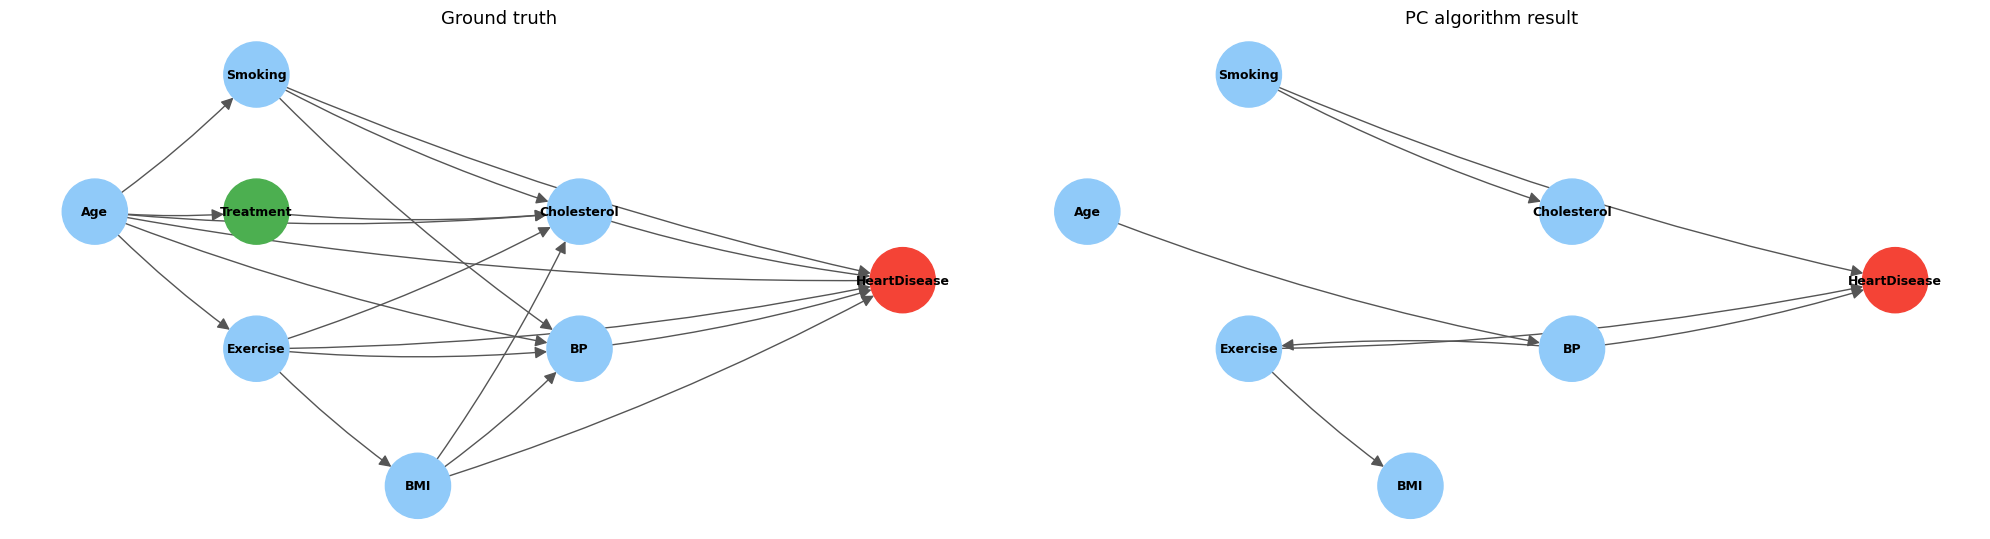

In [8]:
from pgmpy.estimators import PC

# pgmpy needs categorical dtypes for discrete tests
df_cat = df.astype('category')

pc = PC(data=df_cat)
dag_pc = pc.estimate(
    variant='stable',
    ci_test='chi_square',
    return_type='dag',     
    significance_level=0.01,
    max_cond_vars=4,
    show_progress=False
)

print("PC algorithm discovered edges:")
for e in dag_pc.edges():
    print(f"  {e[0]:>12s} -> {e[1]}")

fig, axes = plt.subplots(1, 2, figsize=(20, 5.5))
plot_dag(list(true_edges), "Ground truth", ax=axes[0])
plot_dag(list(dag_pc.edges()), "PC algorithm result", ax=axes[1])

plt.tight_layout(); plt.show()


###  Hybrid: discovery + expert knowledge

Pure data-driven discovery is fragile. In practice, **always** encode obvious domain constraints:

- Nothing causes `Age` (it's exogenous).
- `HeartDisease` is the outcome — nothing flows out of it.
- `Treatment` is a clinical decision — it doesn't cause demographic variables.

`pgmpy` accepts these via the `ExpertKnowledge` class.

In [9]:
forbidden_edges = []
all_vars = list(df.columns)

# Nothing causes Age
for v in all_vars:
    if v != 'Age':
        forbidden_edges.append((v, 'Age'))

# Nothing flows out of HeartDisease (it's the outcome)
for v in all_vars:
    if v != 'HeartDisease':
        forbidden_edges.append(('HeartDisease', v))

# Treatment is a medical decision; it doesn't cause demographics/lifestyle
for v in ['Age', 'Smoking', 'Exercise', 'BMI']:
    forbidden_edges.append(('Treatment', v))

print(forbidden_edges)
ek = ExpertKnowledge(forbidden_edges=forbidden_edges)

[('Smoking', 'Age'), ('Exercise', 'Age'), ('BMI', 'Age'), ('Treatment', 'Age'), ('Cholesterol', 'Age'), ('BP', 'Age'), ('HeartDisease', 'Age'), ('HeartDisease', 'Age'), ('HeartDisease', 'Smoking'), ('HeartDisease', 'Exercise'), ('HeartDisease', 'BMI'), ('HeartDisease', 'Treatment'), ('HeartDisease', 'Cholesterol'), ('HeartDisease', 'BP'), ('Treatment', 'Age'), ('Treatment', 'Smoking'), ('Treatment', 'Exercise'), ('Treatment', 'BMI')]


PC algorithm discovered edges:
            BP -> HeartDisease
            BP -> Exercise
       Smoking -> HeartDisease
       Smoking -> Cholesterol
      Exercise -> BMI
      Exercise -> HeartDisease
           Age -> BP


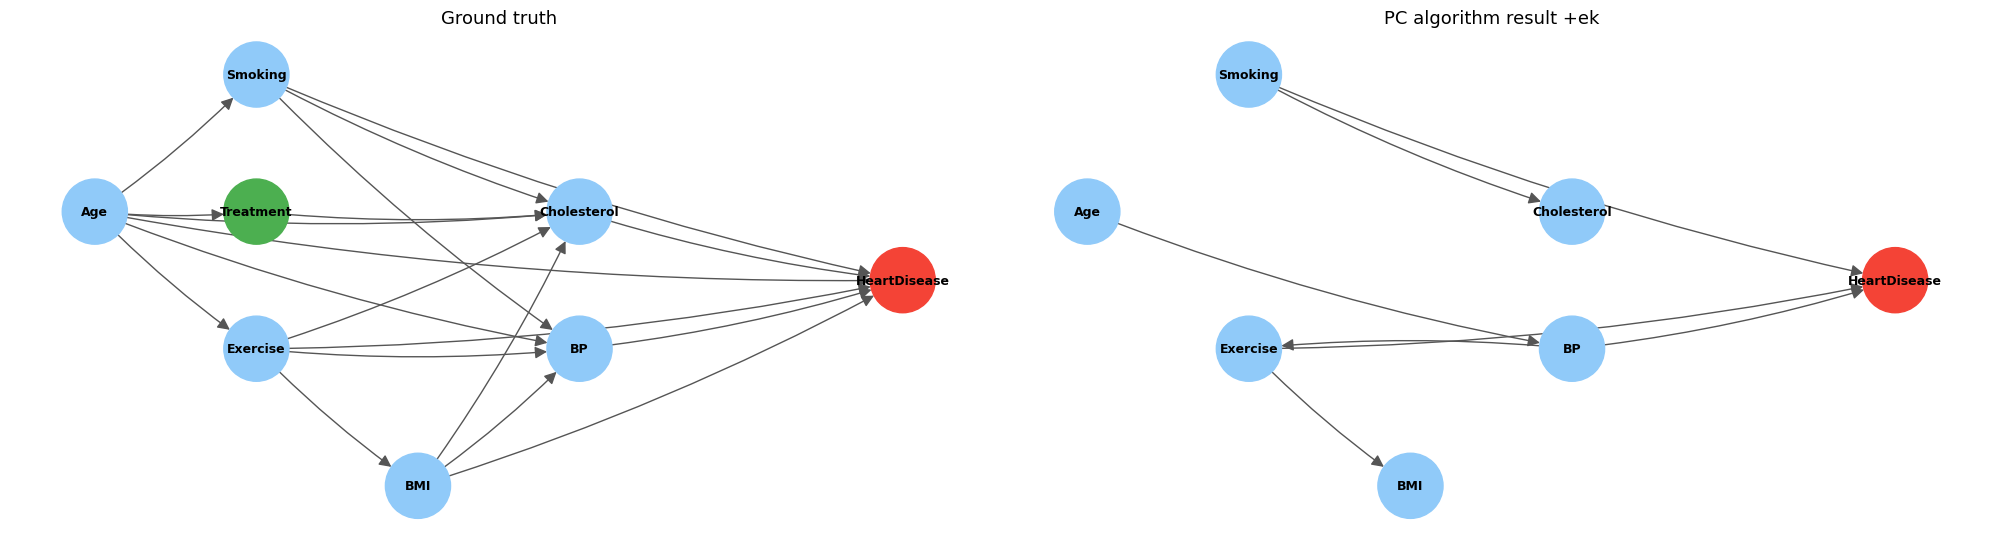

In [10]:
pc = PC(data=df_cat)
dag_pc_ek = pc.estimate(
    variant='stable',
    ci_test='chi_square',#'g_sq', 'Log_likelihood'
    return_type='dag',     
    significance_level=0.01,
    max_cond_vars=8,
    expert_knowledge=ek,
    show_progress=False
)

print("PC algorithm discovered edges:")
for e in dag_pc_ek.edges():
    print(f"  {e[0]:>12s} -> {e[1]}")


fig, axes = plt.subplots(1, 2, figsize=(20, 5.5))
plot_dag(list(true_edges), "Ground truth", ax=axes[0])
plot_dag(list(dag_pc_ek.edges()), "PC algorithm result +ek", ax=axes[1])

plt.tight_layout(); plt.show()

###  Hill-Climb Search with BIC

Score-based methods search the space of DAGs to maximize a goodness-of-fit score. **BIC** (Bayesian Information Criterion) penalizes complexity, which helps avoid spurious edges.

For discrete data we use `scoring_method='bic-d'`. (For continuous data, you'd use `'bic-g'`.)

Hill-Climb (BIC) discovered edges:
      Exercise -> BMI
           BMI -> Smoking
     Treatment -> Cholesterol
     Treatment -> Age
   Cholesterol -> BMI
            BP -> HeartDisease
            BP -> Exercise
            BP -> Treatment
  HeartDisease -> Cholesterol
  HeartDisease -> Exercise
  HeartDisease -> Age
  HeartDisease -> Smoking


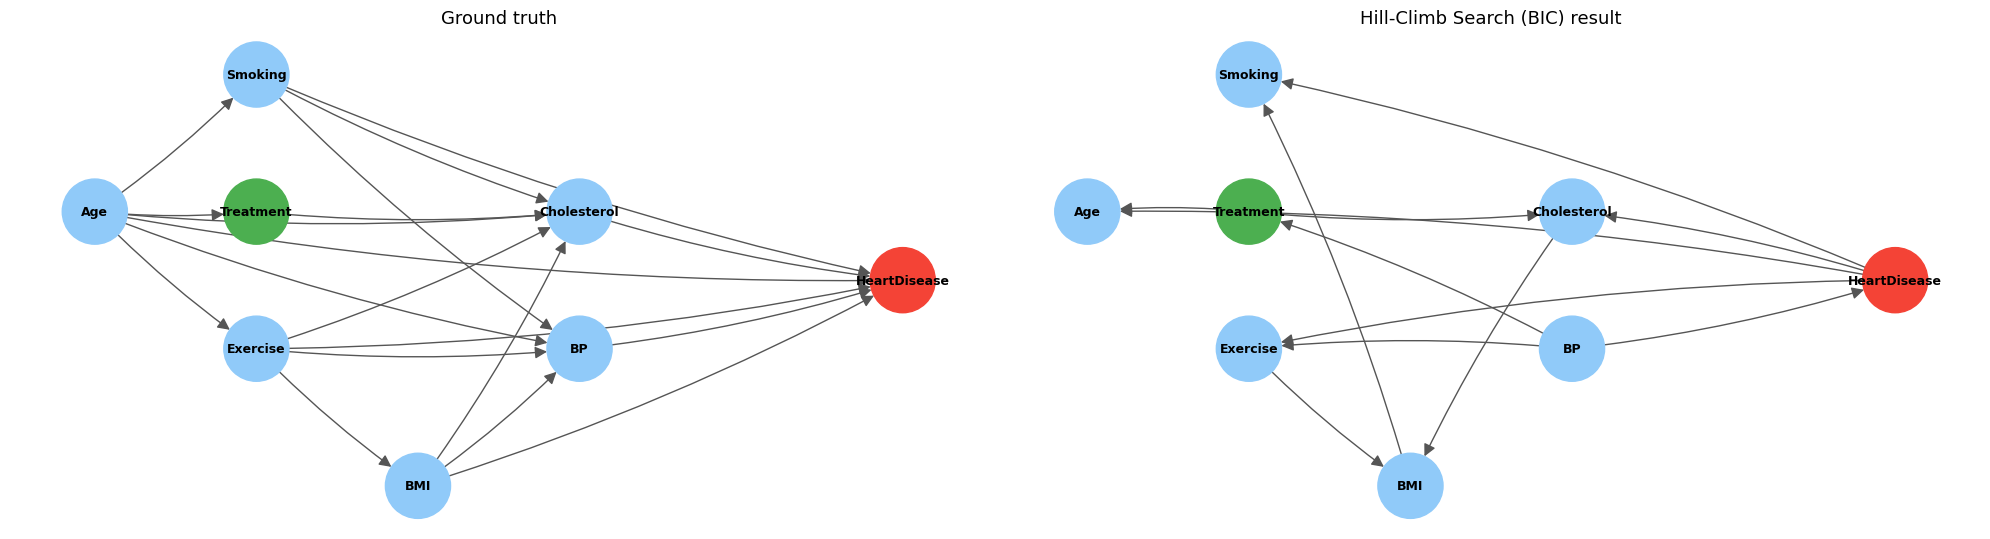

In [11]:
hc = HillClimbSearch(data=df_cat)
dag_hc = hc.estimate(scoring_method='bic-d', #k2, bdeu, aic-d
                      max_indegree=2,         # at most 3 parents per node 
                      show_progress=False)

print("Hill-Climb (BIC) discovered edges:")
for e in dag_hc.edges():
    print(f"  {e[0]:>12s} -> {e[1]}")

fig, axes = plt.subplots(1, 2, figsize=(20, 5.5))
plot_dag(list(true_edges), "Ground truth", ax=axes[0])
plot_dag(list(dag_hc.edges()), "Hill-Climb Search (BIC) result", ax=axes[1])

plt.tight_layout(); plt.show()

Hybrid: discovery + expert knowledge

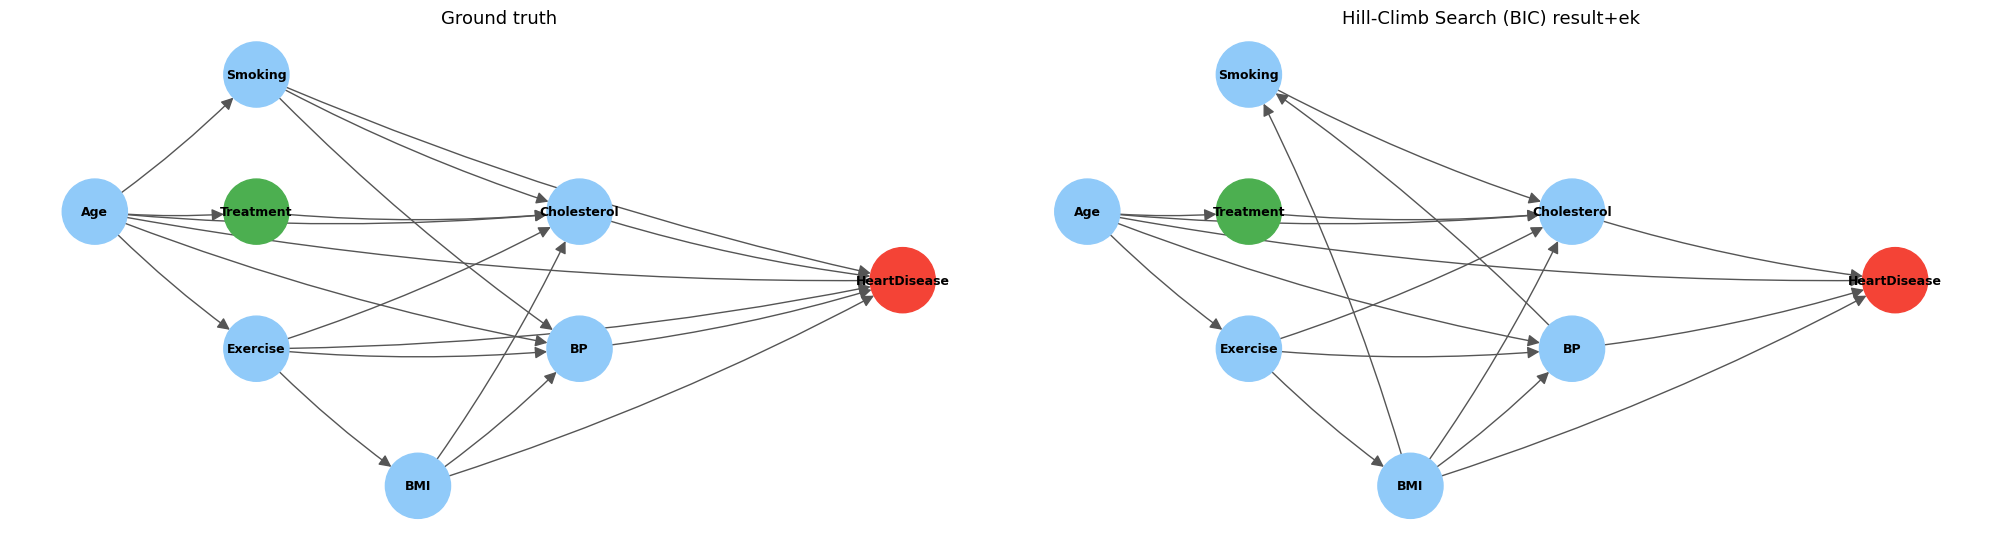

In [12]:
hc_ek = HillClimbSearch(data=df_cat)
dag_hc_ek = hc_ek.estimate(
    scoring_method='bic-d',
    expert_knowledge=ek,
    show_progress=False
)
fig, axes = plt.subplots(1, 2, figsize=(20, 5.5))
plot_dag(list(true_edges), "Ground truth", ax=axes[0])
plot_dag(list(dag_hc_ek.edges()), "Hill-Climb Search (BIC) result+ek", ax=axes[1])

plt.tight_layout(); plt.show()

  0%|          | 17/1000000 [00:00<9:00:49, 30.82it/s]


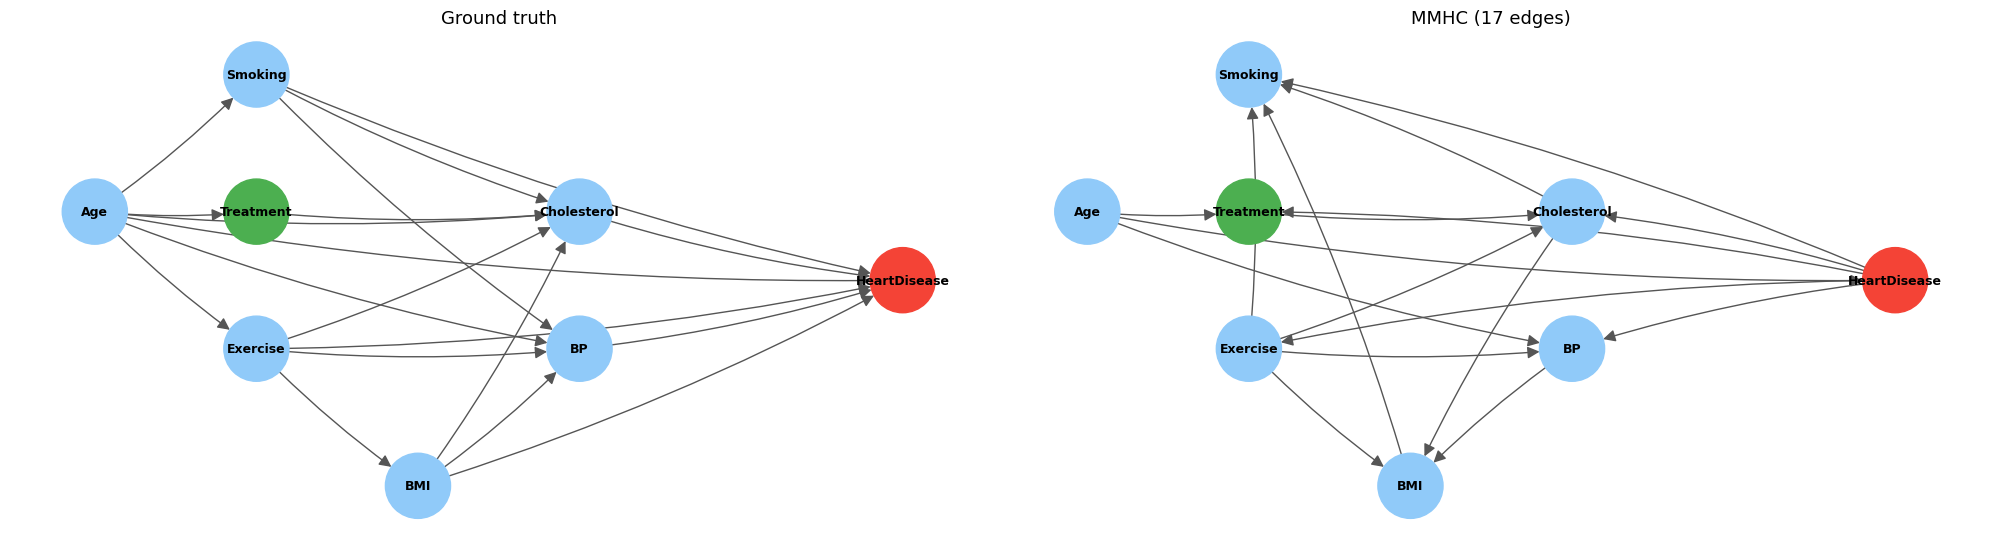

In [13]:
from pgmpy.estimators import MmhcEstimator

mmhc = MmhcEstimator(data=df_cat)
dag_mmhc = mmhc.estimate(scoring_method=None, significance_level=0.05)

fig, axes = plt.subplots(1, 2, figsize=(20, 5.5))
plot_dag(list(true_edges), "Ground truth", ax=axes[0])
plot_dag(list(dag_mmhc.edges()), f"MMHC ({len(list(dag_mmhc.edges()))} edges)", ax=axes[1])
plt.tight_layout(); plt.show()

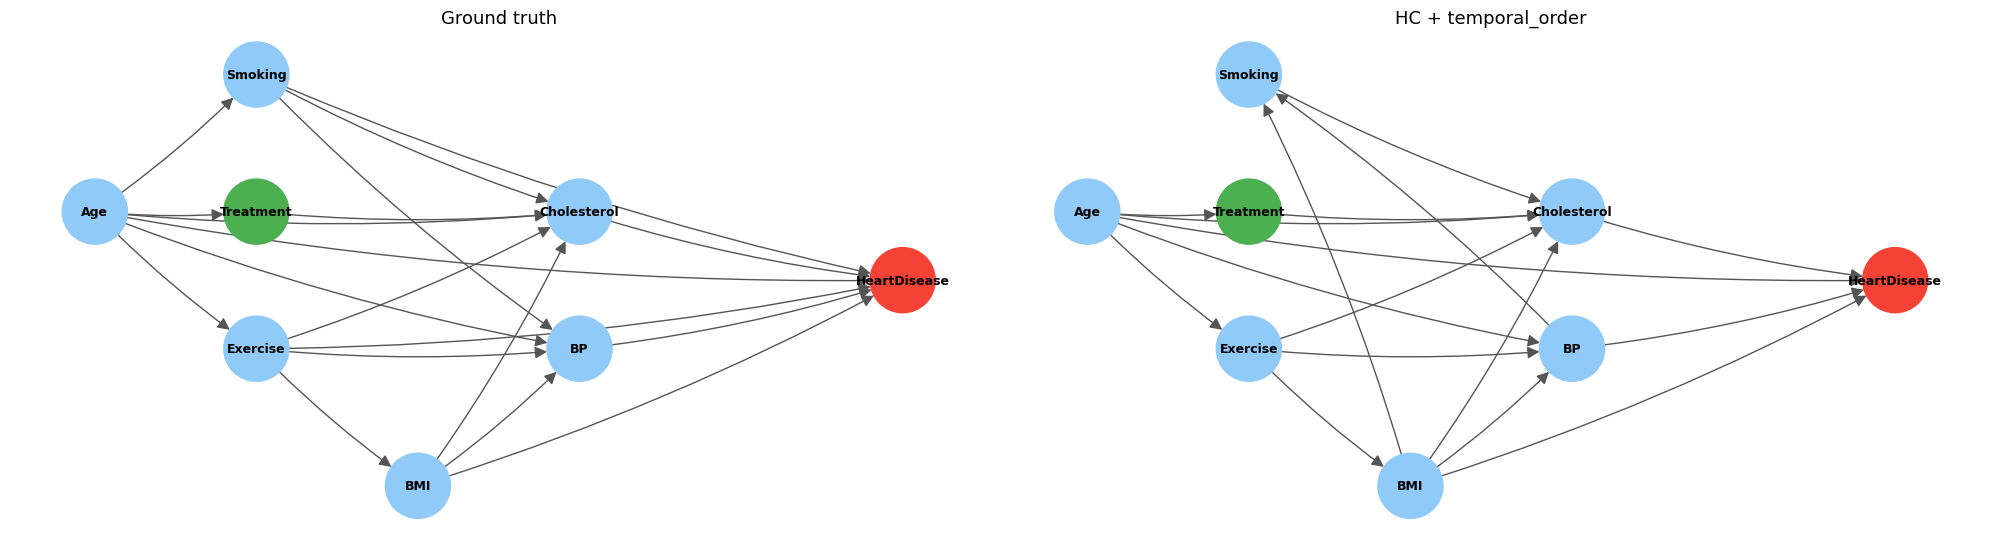

In [14]:
ek_temporal = ExpertKnowledge(
    temporal_order=[
        ['Age'],     # tier 0: immutable / inherited
        ['moking', 'Exercise','Treatment'],         # tier 1: lifestyle
        ['BMI'],           # tier 2: physiology
        ['Cholesterol', 'BP'],            # tier 3: biomarkers
        ['HeartDisease'],                 # tier 4: outcome
    ],
)

hc = HillClimbSearch(data=df_cat)
dag_hc_temp = hc.estimate(scoring_method='bic-d', expert_knowledge=ek_temporal, show_progress=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 5.5))
plot_dag(list(true_edges),                "Ground truth",           ax=axes[0])
plot_dag(list(dag_hc_temp.edges()), "HC + temporal_order",    ax=axes[1])
plt.tight_layout(); plt.show()

## Causal inference with `DoWhy`

Now that we have a graph, we can estimate the causal effect of `Treatment` on `HeartDisease`.

`DoWhy` follows a principled **four-step pipeline** that separates causal *assumptions* from statistical *estimation*:

1. **Model** — encode the causal graph and pick a treatment and outcome.
2. **Identify** — use graph rules (do-calculus, backdoor criterion) to derive an estimand: a formula that expresses the causal effect in terms of observable quantities.
3. **Estimate** — fit a statistical model (regression, matching, IPW…) to compute that estimand from data.
4. **Refute** — challenge the result with sensitivity tests and placebo checks.

This separation matters: most analysts conflate steps 2 and 3, which is why so much applied work confuses correlation with causation.

In [15]:
def pgmpy_to_gml(dag, all_nodes=None):
    """Convert a pgmpy DAG (or list of edges) to a GML string for DoWhy."""
    edges = list(dag.edges()) if hasattr(dag, 'edges') else list(dag)
    nodes = set()
    for u, v in edges:
        nodes.update([u, v])
    if all_nodes is not None:
        nodes.update(all_nodes)  # ensure isolated variables are included

    lines = ['graph [directed 1']
    for n in nodes:
        lines.append(f'  node [id "{n}" label "{n}"]')
    for u, v in edges:
        lines.append(f'  edge [source "{u}" target "{v}"]')
    lines.append(']')
    return '\n'.join(lines)

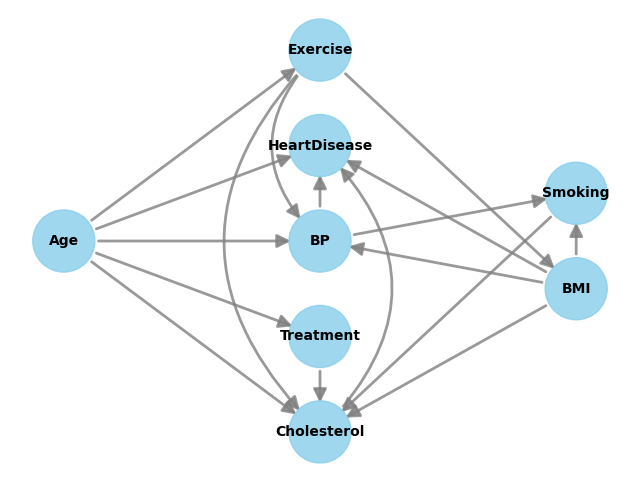

In [16]:
from dowhy import CausalModel

graph_gml = pgmpy_to_gml(dag_hc_temp, all_nodes=df_cat.columns)
df1=df_cat.copy()
df1 = df1.astype('float')
model = CausalModel(
    data=df1,
    treatment='Treatment',
    outcome='HeartDisease',
    graph=graph_gml,
)

try:
    model.view_model()
except Exception:
    print("(Skipping model.view_model() — graphviz not available; we already have plots above.)")

###  Identify the estimand

`DoWhy` searches for ways to express the causal effect using only observed variables. It tries:

- **Backdoor adjustment** — condition on a set that blocks all confounding paths.
- **Frontdoor adjustment** — when no backdoor adjustment exists but a mediator is observed.

In [17]:
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)
print("\nBackdoor adjustment set:", identified_estimand.get_backdoor_variables())

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                           
────────────(E[HeartDisease|Age])
d[Treatment]                     
Estimand assumption 1, Unconfoundedness: If U→{Treatment} and U→HeartDisease then P(HeartDisease|Treatment,Age,U) = P(HeartDisease|Treatment,Age)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
     d                           
────────────(E[HeartDisease|Age])
d[Treatment]                     
Estimand assumption 1, Unconfoundedness: If U→{Treatment} and U→HeartDisease then P(HeartDisease|Treatment,Age,U) = P(HeartDisease|Treatment,Age)


Backdoor adjustment set: ['Age']


### eEstimate the ATE

`DoWhy` supports many backdoor estimators. We'll compare three:

- **Linear regression** — fastest; assumes linear treatment effect (fine for binary outcomes if you only want the ATE).
- **Propensity Score Matching (PSM)** — pairs treated and untreated patients with similar propensity scores.
- **Inverse Propensity Weighting (IPW)** — re-weights observations to balance the treated/untreated populations.

In [18]:
methods = [
    ('Linear regression',    'backdoor.linear_regression',           {}),
    ('Propensity weighting', 'backdoor.propensity_score_weighting',  {'method_params': {'weighting_scheme': 'ips_weight'}}),
]

ate_results = []
print(f"\n{'Naive (no adjustment)':>22s}: ATE = {naive_ate[1] - naive_ate[0]:+.4f}")
for name, method, kwargs in methods:
    est = model.estimate_effect(identified_estimand, method_name=method, **kwargs,confidence_intervals=True)
    ate_results.append({'Method': name, 'ATE': est.value})
    print(f"{name:>22s}: ATE = {est.value:+.4f}")


 Naive (no adjustment): ATE = +0.0399
     Linear regression: ATE = -0.1325
  Propensity weighting: ATE = -0.1265


## Diagnostic plots: outcome distribution and propensity overlap

Before fitting heterogeneous-effect models it is worth eyeballing two things:

1. **How the outcome (HeartDisease) splits across pre-treatment variables, separately for treated and untreated patients.** Differences here are a mix of treatment effect *and* confounding — older patients have both more disease and more treatment, so a raw gap is misleading. Still, the picture tells us where treatment is concentrated and how the outcome varies.
2. **The propensity score distribution by treatment group.** This is the standard *positivity / overlap* check: every region of covariate space should contain both treated and untreated patients, otherwise no estimator can identify a causal effect there.

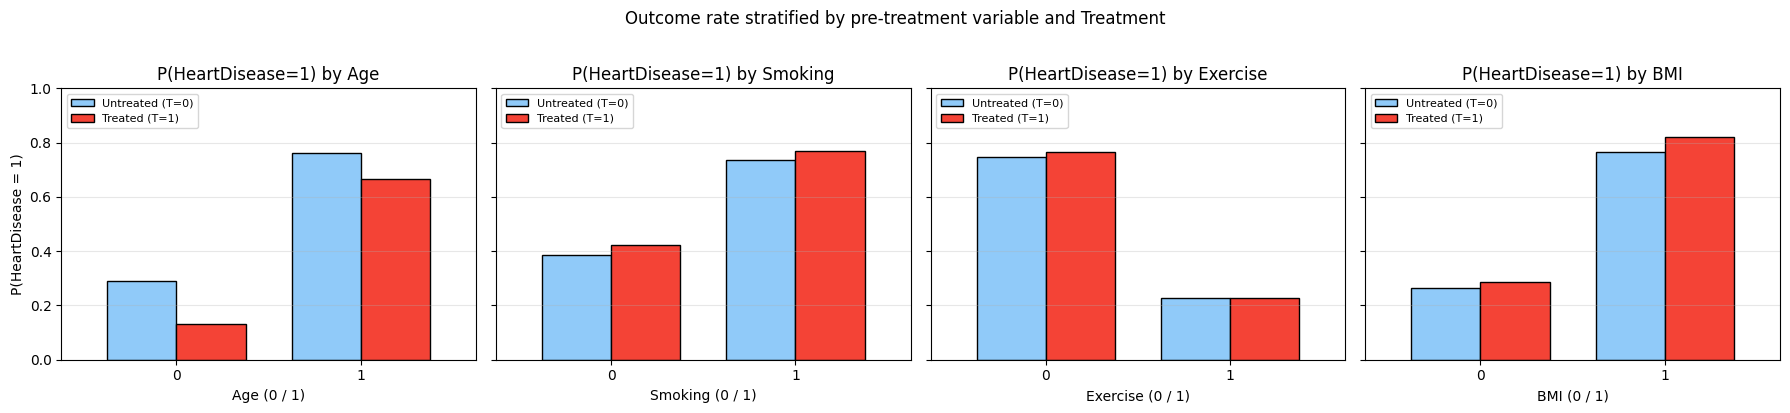

In [19]:
# Pre-treatment variables — these are legitimate confounders / effect modifiers
pre_treatment = ['Age', 'Smoking', 'Exercise', 'BMI']

fig, axes = plt.subplots(1, len(pre_treatment), figsize=(18, 4), sharey=True)
for ax, var in zip(axes, pre_treatment):
    # P(HeartDisease = 1) at each level of `var`, split by Treatment
    sub = df.groupby([var, 'Treatment'])['HeartDisease'].mean().unstack('Treatment')
    sub.columns = [f"Untreated (T=0)", f"Treated (T=1)"]
    sub.plot(kind='bar', ax=ax, color=['#90CAF9', '#F44336'],
             edgecolor='black', width=0.75)
    ax.set_title(f'P(HeartDisease=1) by {var}')
    ax.set_xlabel(f'{var} (0 / 1)')
    ax.set_xticklabels([0, 1], rotation=0)
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8, loc='upper left')
axes[0].set_ylabel('P(HeartDisease = 1)')
plt.suptitle("Outcome rate stratified by pre-treatment variable and Treatment", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

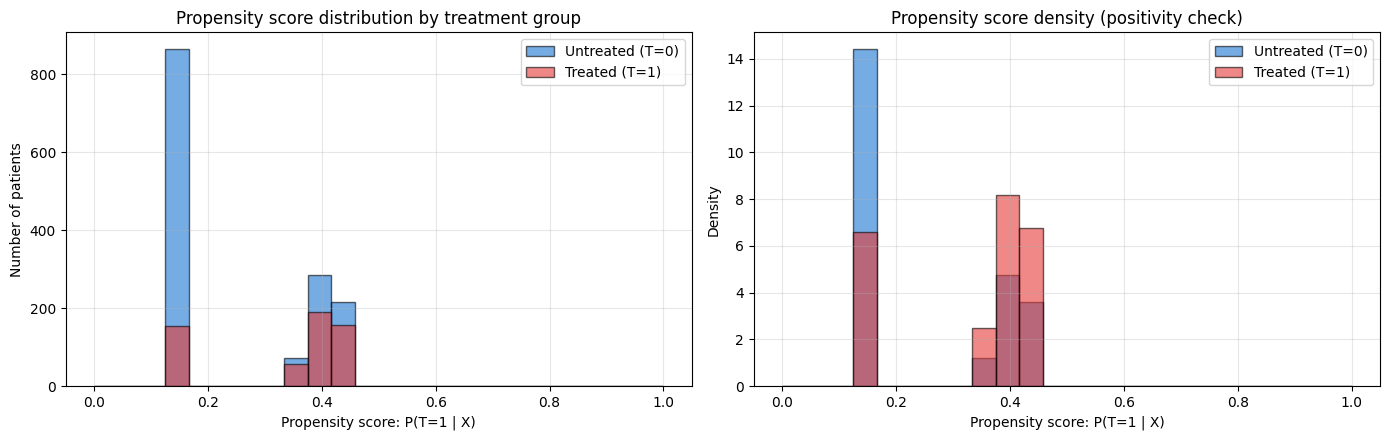

Propensity range:        [0.128, 0.441]
Treated   group mean ps: 0.342
Untreated group mean ps: 0.256


In [21]:
from sklearn.linear_model import LogisticRegression

X_pre = df[pre_treatment].values
T = df['Treatment'].values

ps_model = LogisticRegression(max_iter=1000).fit(X_pre, T)
ps = ps_model.predict_proba(X_pre)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Histogram of propensity scores by treatment group
bins = np.linspace(0, 1, 25)
axes[0].hist(ps[T == 0], bins=bins, alpha=0.6, label='Untreated (T=0)',
             color='#1976D2', edgecolor='black')
axes[0].hist(ps[T == 1], bins=bins, alpha=0.6, label='Treated (T=1)',
             color='#E53935', edgecolor='black')
axes[0].set_xlabel('Propensity score: P(T=1 | X)')
axes[0].set_ylabel('Number of patients')
axes[0].set_title('Propensity score distribution by treatment group')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Same data as densities — easier to compare overlap when group sizes differ
axes[1].hist(ps[T == 0], bins=bins, alpha=0.6, label='Untreated (T=0)',
             color='#1976D2', edgecolor='black', density=True)
axes[1].hist(ps[T == 1], bins=bins, alpha=0.6, label='Treated (T=1)',
             color='#E53935', edgecolor='black', density=True)
axes[1].set_xlabel('Propensity score: P(T=1 | X)')
axes[1].set_ylabel('Density')
axes[1].set_title('Propensity score density (positivity check)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Propensity range:        [{ps.min():.3f}, {ps.max():.3f}]")
print(f"Treated   group mean ps: {ps[T == 1].mean():.3f}")
print(f"Untreated group mean ps: {ps[T == 0].mean():.3f}")

##  Heterogeneous treatment effects: EconML metalearners with TabPFN

The DoWhy estimates above give a single number — the average treatment effect (ATE). But the effect of statins almost certainly differs across patients: an older smoker with high BMI may benefit more (or less) than a young non-smoker. **CATE** — the *Conditional* Average Treatment Effect — captures this heterogeneity:

$$\tau(x) \;=\; \mathbb{E}\bigl[\,Y(1) - Y(0) \mid X = x\,\bigr]$$

We use three metalearners from EconML, each a different recipe for turning regression models into CATE estimators:

| Learner | Idea |
|---|---|
| **S-Learner** | Fit one model `μ(X, T) → Y`; CATE is `μ(X, 1) − μ(X, 0)`. |
| **T-Learner** | Fit two separate models `μ₀(X)` on untreated and `μ₁(X)` on treated; CATE is `μ₁ − μ₀`. |
| **X-Learner** | T-Learner + a propensity-weighted refinement that helps when the treated/untreated groups are very unbalanced. |

For the base regressors we use **TabPFN** — a transformer pre-trained on millions of synthetic tabular tasks, which often beats gradient boosting on small datasets without any tuning. Install with:

```bash
pip install tabpfn econml
```

> If you do not have a GPU, pass `device='cpu'` to `TabPFNRegressor` / `TabPFNClassifier`. TabPFN works fine on CPU for n ≲ 10k.

In [24]:
# Install if missing:
# !pip install tabpfn econml

from tabpfn import TabPFNClassifier, TabPFNRegressor
from econml.metalearners import SLearner, TLearner, XLearner
import os
from dotenv import load_dotenv

# Load from .env file
load_dotenv()

# Now use the token
token = os.environ.get("TABPFN_TOKEN")
if not token:
    raise ValueError("TABPFN_TOKEN not found. Please set it in .env file")

# Your code here
import os; os.environ["TABPFN_TOKEN"] = token
# Pick device automatically — fall back to CPU
try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"
print(f"TabPFN device: {DEVICE}")

# CATE features: pre-treatment variables only.
# Cholesterol / BP are post-treatment (Treatment causes Cholesterol in the DAG),
# so conditioning on them would block the very effect we are trying to estimate.
X = df[pre_treatment].values
T = df['Treatment'].values
Y = df['HeartDisease'].values

print(f"X shape: {X.shape}   |   features: {pre_treatment}")
print(f"Treated: {T.sum()} / {len(T)}   |   Outcome positives: {Y.sum()} / {len(Y)}")

TabPFN device: cpu
X shape: (2000, 4)   |   features: ['Age', 'Smoking', 'Exercise', 'BMI']
Treated: 561 / 2000   |   Outcome positives: 980 / 2000


In [25]:
# Helper: fresh TabPFN instance per call (EconML's metalearners
# clone the model internally for each fold/group).
def make_tabpfn_regressor():
    return TabPFNRegressor(device=DEVICE, ignore_pretraining_limits=True)

def make_tabpfn_classifier():
    return TabPFNClassifier(device=DEVICE, ignore_pretraining_limits=True)

# ---- S-Learner -------------------------------------------------------------
s_learner = SLearner(overall_model=make_tabpfn_regressor())
s_learner.fit(Y, T, X=X)
cate_s = s_learner.effect(X)

# ---- T-Learner -------------------------------------------------------------
t_learner = TLearner(models=make_tabpfn_regressor())
t_learner.fit(Y, T, X=X)
cate_t = t_learner.effect(X)

# ---- X-Learner -------------------------------------------------------------
x_learner = XLearner(
    models=make_tabpfn_regressor(),
    propensity_model=make_tabpfn_classifier(),
)
x_learner.fit(Y, T, X=X)
cate_x = x_learner.effect(X)

print(f"\n{'Learner':<12s}{'ATE (mean CATE)':>20s}{'CATE std':>12s}{'CATE min':>12s}{'CATE max':>12s}")
print("-" * 68)
for name, c in [('S-Learner', cate_s), ('T-Learner', cate_t), ('X-Learner', cate_x)]:
    print(f"{name:<12s}{c.mean():>+20.4f}{c.std():>12.4f}{c.min():>+12.4f}{c.max():>+12.4f}")


Learner          ATE (mean CATE)    CATE std    CATE min    CATE max
--------------------------------------------------------------------
S-Learner                -0.0960      0.1078     -0.2945     -0.0012
T-Learner                -0.1070      0.1288     -0.3872     +0.0030
X-Learner                -0.1088      0.1215     -0.3143     +0.0008


##  Heterogeneous treatment effects: EconML metalearners with sklearn

In [28]:
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier

def make_regressor():
    return GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=0)

def make_classifier():
    return GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=0)

# ---- S-Learner -------------------------------------------------------------
s_learner = SLearner(overall_model=make_regressor())
s_learner.fit(Y, T, X=X)
cate_s = s_learner.effect(X)

# ---- T-Learner -------------------------------------------------------------
t_learner = TLearner(models=make_regressor())
t_learner.fit(Y, T, X=X)
cate_t = t_learner.effect(X)

# ---- X-Learner -------------------------------------------------------------
x_learner = XLearner(
    models=make_regressor(),
    propensity_model=make_classifier(),
)
x_learner.fit(Y, T, X=X)
cate_x = x_learner.effect(X)

print(f"\n{'Learner':<12s}{'ATE (mean CATE)':>20s}{'CATE std':>12s}{'CATE min':>12s}{'CATE max':>12s}")
print("-" * 68)
for name, c in [('S-Learner', cate_s), ('T-Learner', cate_t), ('X-Learner', cate_x)]:
    print(f"{name:<12s}{c.mean():>+20.4f}{c.std():>12.4f}{c.min():>+12.4f}{c.max():>+12.4f}")


Learner          ATE (mean CATE)    CATE std    CATE min    CATE max
--------------------------------------------------------------------
S-Learner                -0.1055      0.0982     -0.3171     +0.0453
T-Learner                -0.1007      0.1116     -0.2936     +0.1638
X-Learner                -0.1009      0.1109     -0.2929     +0.1493


### Comparing to the DoWhy ATE

The metalearner ATEs (the means of the CATE distributions above) should land in the same neighbourhood as the DoWhy backdoor estimates from earlier in the notebook. Differences come from two places:

1. **Adjustment set.** DoWhy used the discovered DAG's backdoor set (`Age` only). The metalearners above condition on all four pre-treatment variables. Conditioning on more pre-treatment variables doesn't bias the ATE here — none of `Smoking`, `Exercise`, `BMI` are colliders or descendants of Treatment in the true graph — but it can change variance.
2. **Functional form.** Linear regression assumes a constant effect. TabPFN does not. If the true effect is heterogeneous, the metalearner ATEs are a weighted average of CATEs and may differ slightly from a pooled linear coefficient.

Both should agree on sign and rough magnitude — that is the sanity check.

                     Method     ATE
      Naive (no adjustment)  0.0399
   DoWhy: Linear regression -0.1325
DoWhy: Propensity weighting -0.1265
           EconML S-Learner -0.1055
           EconML T-Learner -0.1007
           EconML X-Learner -0.1009


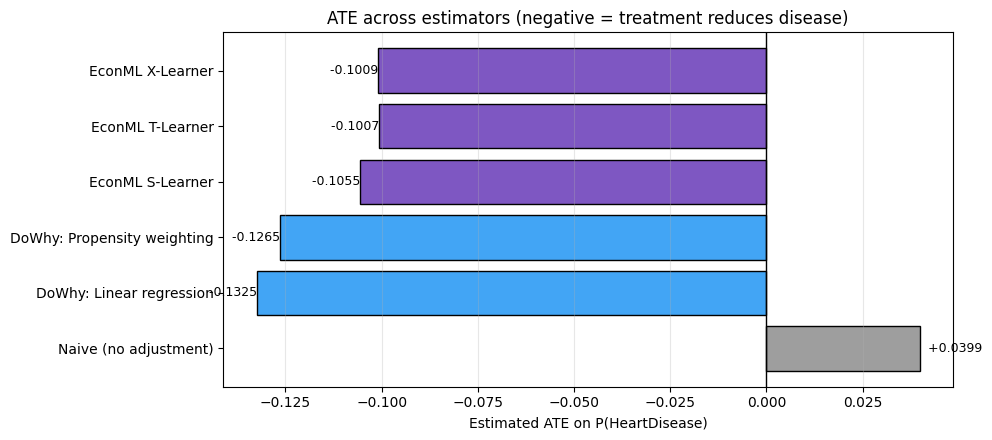

In [29]:
ate_summary = pd.DataFrame({
    'Method': [
        'Naive (no adjustment)',
        'DoWhy: Linear regression',
        'DoWhy: Propensity weighting',
        'EconML S-Learner',
        'EconML T-Learner',
        'EconML X-Learner',
    ],
    'ATE': [
        naive_ate[1] - naive_ate[0],
        ate_results[0]['ATE'],   # linear regression
        ate_results[1]['ATE'],   # propensity weighting
        cate_s.mean(),
        cate_t.mean(),
        cate_x.mean(),
    ],
})
ate_summary['ATE'] = ate_summary['ATE'].round(4)
print(ate_summary.to_string(index=False))

# Bar chart of all estimates
fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ['#9E9E9E', '#42A5F5', '#42A5F5', '#7E57C2', '#7E57C2', '#7E57C2']
bars = ax.barh(ate_summary['Method'], ate_summary['ATE'],
               color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Estimated ATE on P(HeartDisease)')
ax.set_title('ATE across estimators (negative = treatment reduces disease)')
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, ate_summary['ATE']):
    ax.text(val, bar.get_y() + bar.get_height() / 2,
            f'  {val:+.4f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()